In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# ============================================================
# 1. Read data
# ============================================================
ncfile = "pattern_index.nc"   # 改成你的实际路径
ds = xr.open_dataset(ncfile)

var_list = [
    ("p_cor_EPElNino", "(a) EP El Niño pattern index"),
    ("p_cor_CPElNino", "(b) CP El Niño pattern index"),
    ("p_cor_LaNina",   "(c) La Niña pattern index"),
]

years = ds["year"].values.astype(int)
n_years = len(years)
n_days = int(ds["day"].size)   # 121

In [17]:
# ============================================================
# 2. Build continuous x-axis
# ============================================================
total_len = n_years * n_days
time_index = np.arange(total_len)

# start / center / end positions of each yearly block
year_start_pos = np.arange(0, total_len, n_days)
year_center_pos = year_start_pos + n_days / 2.0
year_end_pos = total_len

tick_positions = year_center_pos
tick_labels = [str(y) for y in years]

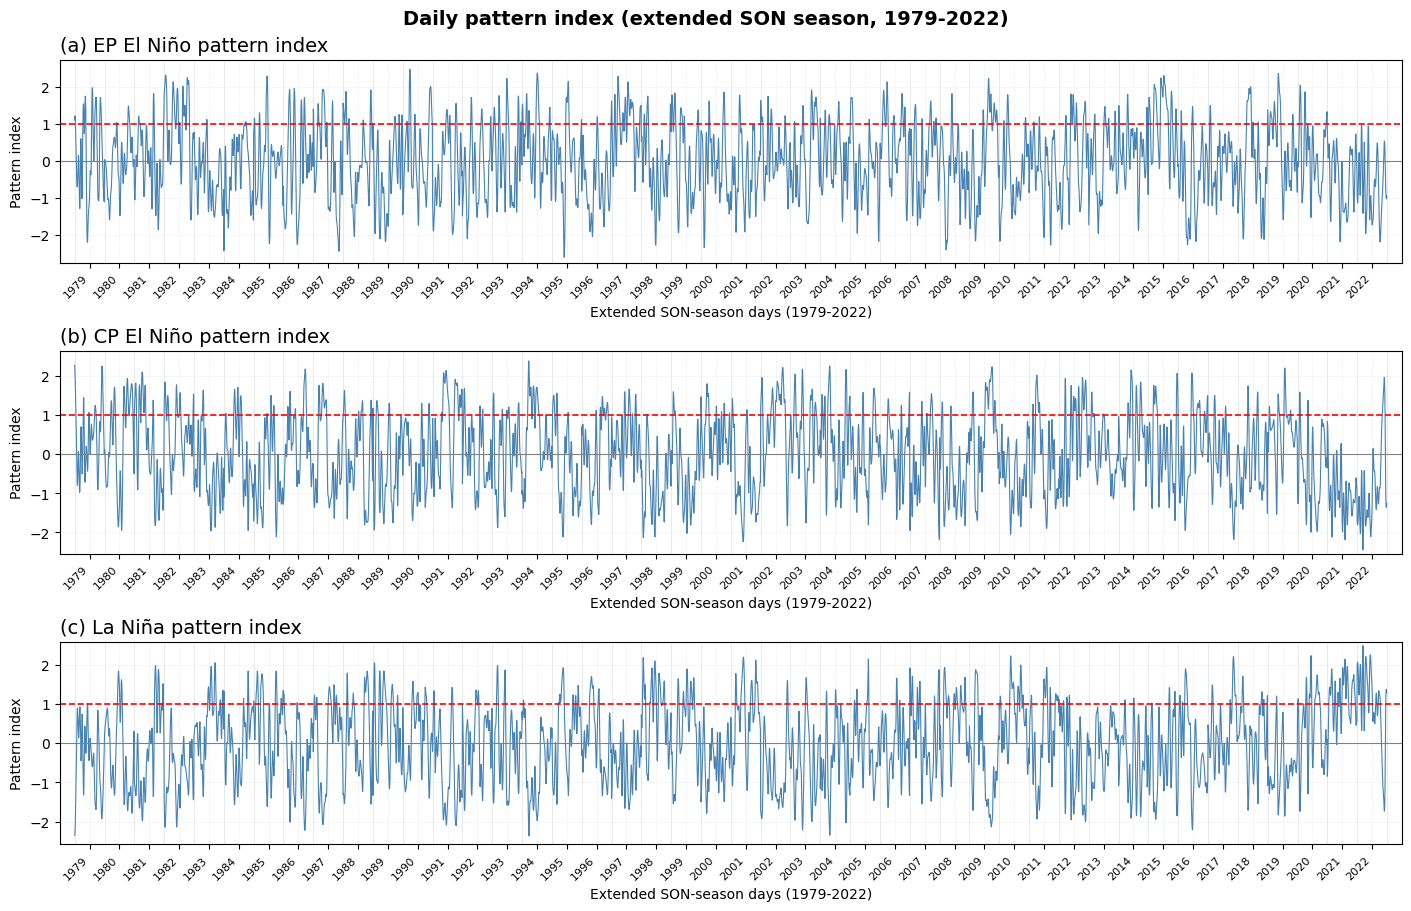

In [25]:
# ============================================================
# 3. Plot
# ============================================================
fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 9),
    sharex=False,
    constrained_layout=True
)

for ax, (vname, title) in zip(axes, var_list):

    # (year, day) -> 1D continuous series
    data_2d = ds[vname].values
    series = data_2d.reshape(-1)

    # Normalize by the standard deviation of the full series
    series = (series-np.nanmean(series)) / np.nanstd(series)

    # Main line
    ax.plot(time_index, series, linewidth=0.8, color="steelblue")

    # Threshold for pattern-day definition
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2)
    ax.axhline(0.0, color="0.5", linewidth=0.8)

    # Year boundary lines, including the rightmost edge
    for pos in year_start_pos:
        ax.axvline(pos, color="0.88", linewidth=0.5, zorder=0)
    ax.axvline(year_end_pos, color="0.88", linewidth=0.5, zorder=0)

    # Symmetric x-limits so both sides look balanced
    ax.set_xlim(-n_days / 2.0, year_end_pos - 1 + n_days / 2.0)

    # X ticks and labels on every panel
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        tick_labels,
        rotation=45,
        ha="right",
        fontsize=8
    )
    ax.tick_params(axis="x", labelbottom=True)

    ax.set_ylabel("Pattern index", fontsize=10)
    ax.set_title(title, loc="left", fontsize=14)
    ax.grid(alpha=0.2, linestyle="--", linewidth=0.5)

    # Robust y-limits
    y_min = np.nanpercentile(series, 1)
    y_max = np.nanpercentile(series, 99)
    pad = 0.15 * (y_max - y_min if y_max > y_min else 1.0)
    ax.set_ylim(y_min - pad, y_max + pad)

# x-axis label on every panel
for ax in axes:
    ax.set_xlabel("Extended SON-season days (1979-2022)", fontsize=10)

fig.suptitle("Daily pattern index (extended SON season, 1979-2022)", fontsize=14,fontweight="bold")

# ============================================================
# 4. Save
# ============================================================
plt.savefig("FigS1.png", dpi=300, bbox_inches="tight")
plt.show()